In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import cariaco_npzd_setups as cns          # NPZD model (replaces cariaco_baseline_setups)
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cns, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cns.phyto_esd, cns.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')
print(f'spec: K_sZ={cns.K_SZ}  σ={cns.SIGMA}  GGE={cns.GGE_VAL}  '
      f'm_Z={cns.M_Z}  m_Zlin={cns.M_ZLIN}  θ_opt={cns.THETA_OPT}  '
      f'fish_rate(default)={cns.FISH_RATE}')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)
spec: K_sZ=0.23  σ=0.15  GGE=0.25  m_Z=0.1  m_Zlin=0.05  θ_opt=10.0  fish_rate(default)=0.0


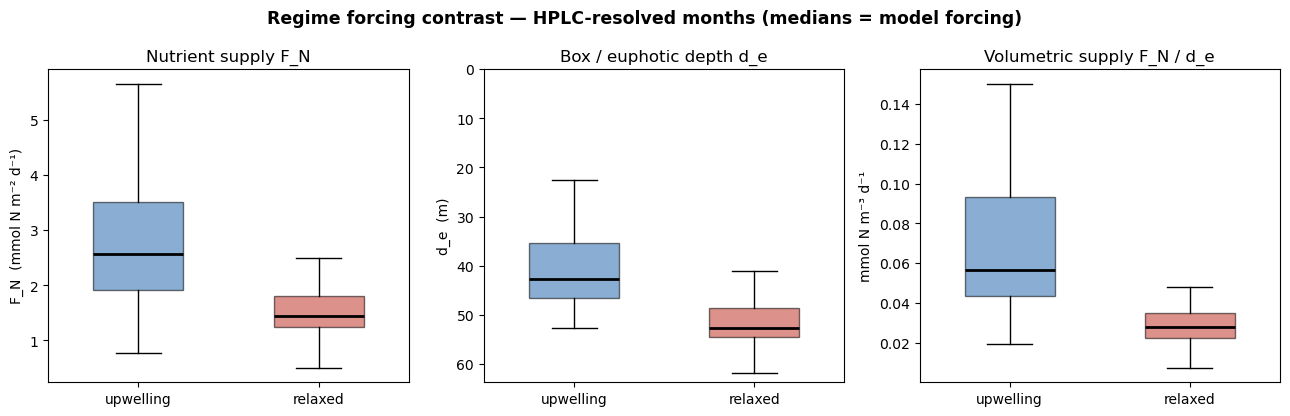

upwelling   n=31   F_N= 2.58   d_e= 42.8   T= 23.0°C   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   T= 25.4°C   F_N/d_e=0.0275


In [2]:
# ── Cell 4 — regime forcing (upwelling vs relaxed, HPLC months, +temperature) ─
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"T={f.get('Temperature__value', float('nan')):5.1f}°C   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

upwelling   CV(ΣP)=0.000   mcs model/obs = 0.63 / 4.84 µm
            model  Pico (<2 µm)=1.00  Nano (2-20 µm)=0.00  Micro (>20 µm)=0.00
            obs    Pico (<2 µm)=0.45  Nano (2-20 µm)=0.22  Micro (>20 µm)=0.31
relaxed     CV(ΣP)=0.000   mcs model/obs = 0.63 / 2.01 µm
            model  Pico (<2 µm)=1.00  Nano (2-20 µm)=0.00  Micro (>20 µm)=0.00
            obs    Pico (<2 µm)=0.61  Nano (2-20 µm)=0.26  Micro (>20 µm)=0.10


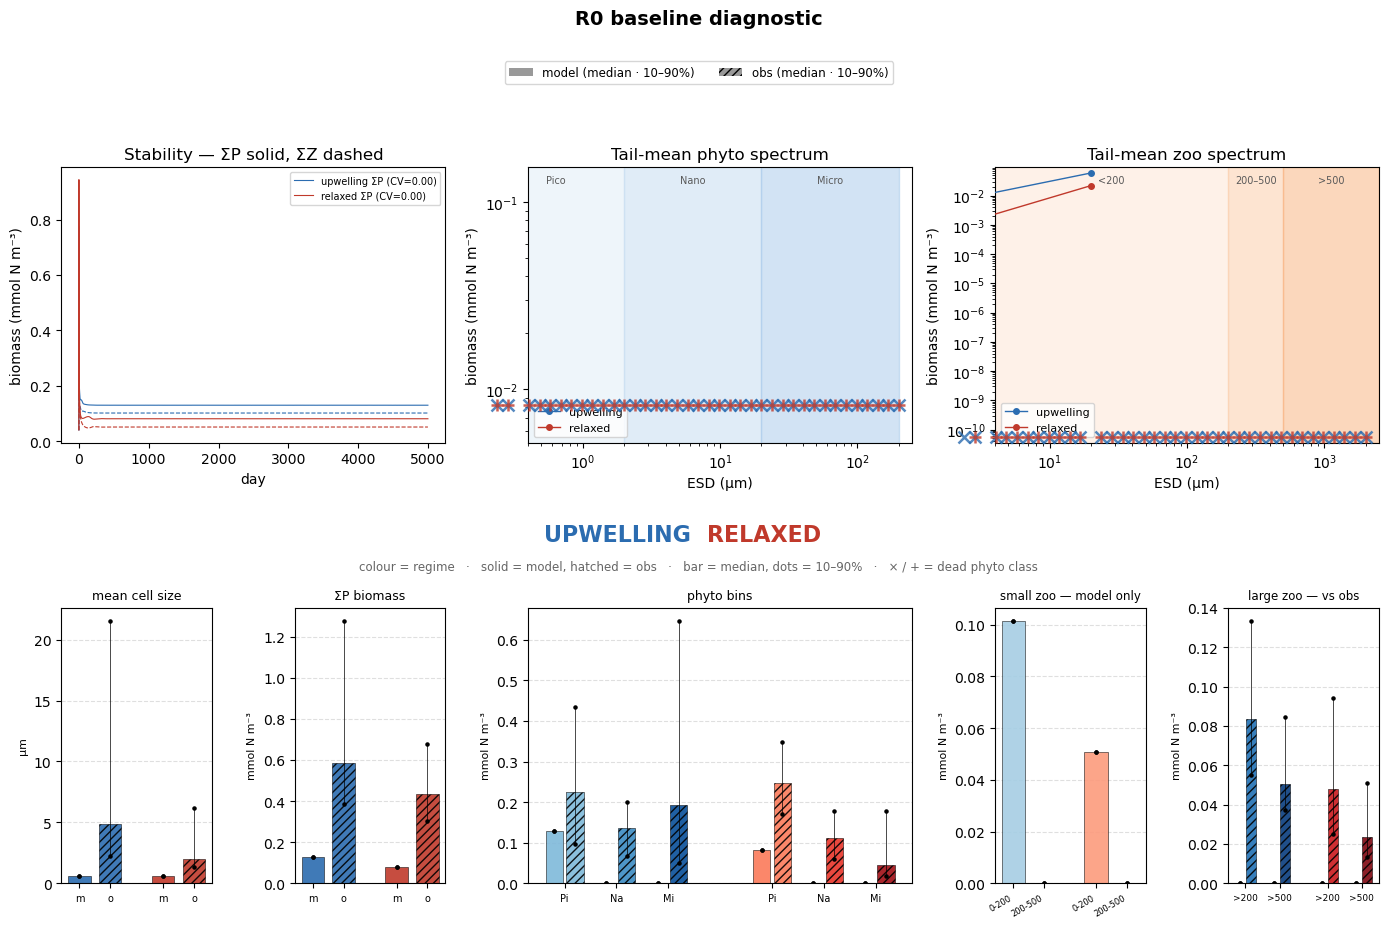

In [3]:
# ── Cell 5 — IVP per regime → tail-mean diagnostic vs obs (fish off) ──────────
TAIL = 1000

def _bin_frac_model(proc):
    pb = np.asarray(proc['phyto_bins_tail'])                       # (n_bins, tail)
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), proc['phyto_bin_labels']

def _bin_frac_obs(obs):
    pb = np.vstack(obs['phyto_bins'])                             # (n_bins, n_months)
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), obs['phyto_bin_labels']

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd,
                              scan_params={}, fixed_overrides=targets[r]['forcing'])
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd, bin_defs,
                                               tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)

    m_mcs = np.nanmedian(model_by_regime[r]['mcs_tail'])
    o_mcs = np.nanmedian(obs_by_regime[r]['mcs'])
    mfr, mlab = _bin_frac_model(model_by_regime[r])
    ofr, olab = _bin_frac_obs(obs_by_regime[r])
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.3f}   "
          f"mcs model/obs = {m_mcs:.2f} / {o_mcs:.2f} µm")
    print("            model  " + "  ".join(f"{l}={v:.2f}" for l, v in zip(mlab, mfr)))
    print("            obs    " + "  ".join(f"{l}={v:.2f}" for l, v in zip(olab, ofr)))

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                phyto_esd, zoo_esd, regimes=regimes)
plt.show()

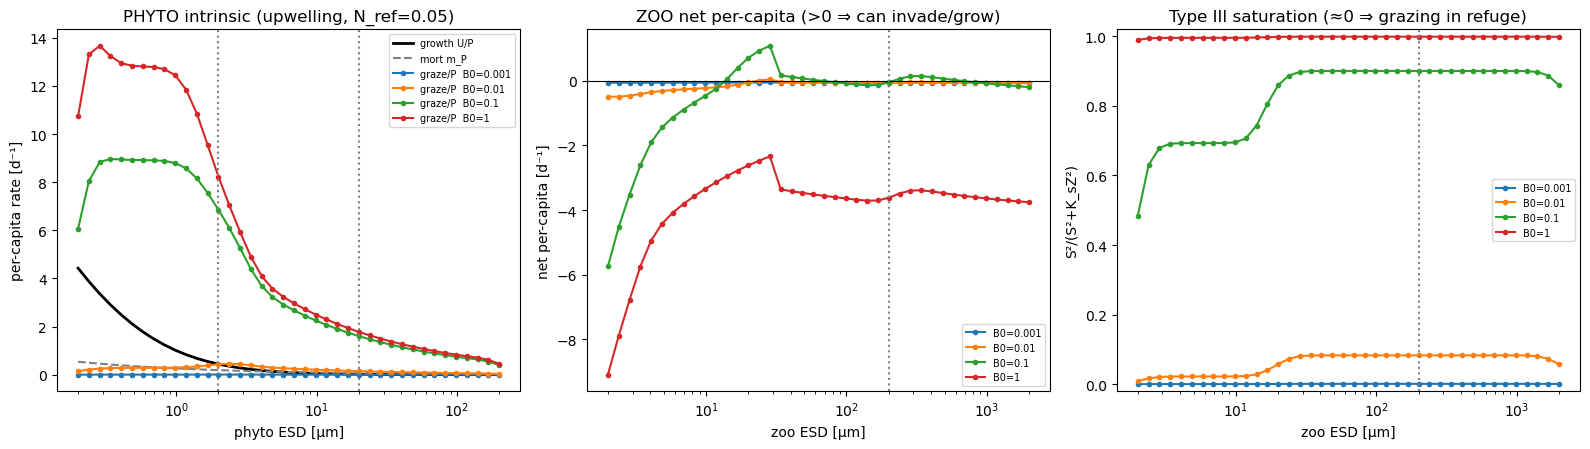

[intrinsic | upwelling | N_ref=0.05 | T=23.0°C | fT_grow=1.16 fT_graze=1.31]
phyto growth U/P: smallest(0.2µm)=4.428  largest(200µm)=0.001 d⁻¹
       B0   maxZnet  argmaxESD   maxSat  maxGrazeP
    1e-03    -0.053       28.5    0.001      0.005
    1e-02     0.044       28.5    0.083      0.455
    1e-01     1.084       28.5    0.900      8.967
    1e+00    -2.338       28.5    0.999     13.669


In [4]:
# ── Cell A — INTRINSIC per-class structure at equal biomass (standalone, from cns) ──
import numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns

REGIME = 'upwelling'
T      = targets[REGIME]['forcing'].get('Temperature__value', cns.T_DEFAULT)
N_ref  = 0.05                                   # set near the run's SS N (Cell B prints it)
B0_sweep = np.array([1e-3, 1e-2, 1e-1, 1.0])    # uniform biomass per class [mmol N m-3]

pe, ze = cns.phyto_esd, cns.zoo_esd
n = cns.N_CLASSES
mu, ks, mP   = cns.mu_max_arr, cns.ks_arr, cns.mP_arr
Imax, KsZ    = cns.Imax_arr, cns.KsZ_arr
phi          = cns.phiPZ_omni                   # (2n, n) prey × predator
GGE, mZ, mZl = cns.GGE_VAL, cns.M_Z, cns.M_ZLIN
fTg = cns.Q10_GROW  ** ((T - cns.T_REF) / 10.0)
fTz = cns.Q10_GRAZE ** ((T - cns.T_REF) / 10.0)

pc_grow  = fTg * mu * N_ref / (N_ref + ks)      # phyto per-capita growth [d-1] (N-dependent only)
pc_mortP = mP                                   # phyto per-capita linear mortality

def intrinsic(B0):
    B = np.full(2 * n, B0)
    S = (phi * B[:, None]).sum(axis=0)                       # (n,) palat-weighted prey per predator
    Z = np.full(n, B0)
    G = fTz * Imax[None, :] * Z[None, :] * phi * B[:, None] * (S / (S**2 + KsZ**2))[None, :]  # (2n,n)
    pc_graze  = G.sum(axis=1) / B0              # per-capita grazing pressure on each prey (2n,)
    pc_ingest = G.sum(axis=0) / B0              # per-capita ingestion per predator (n,)
    sat       = S**2 / (S**2 + KsZ**2)          # community Type III saturation (0..1)
    return pc_graze[:n], pc_graze[n:], pc_ingest, sat

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].plot(pe, pc_grow, 'k-', lw=2, label='growth U/P')
ax[0].plot(pe, pc_mortP, color='grey', ls='--', label='mort m_P')
for B0 in B0_sweep:
    gP, gZ, ing, sat = intrinsic(B0)
    ax[0].plot(pe, gP, 'o-', ms=3, label=f'graze/P  B0={B0:g}')
ax[0].axvline(2, c='grey', ls=':'); ax[0].axvline(20, c='grey', ls=':')
ax[0].set_xscale('log'); ax[0].set_xlabel('phyto ESD [µm]'); ax[0].set_ylabel('per-capita rate [d⁻¹]')
ax[0].set_title(f'PHYTO intrinsic ({REGIME}, N_ref={N_ref:g})'); ax[0].legend(fontsize=7)

for B0 in B0_sweep:
    gP, gZ, ing, sat = intrinsic(B0)
    net = GGE * ing - gZ - mZ * (n * B0) - mZl
    ax[1].plot(ze, net, 'o-', ms=3, label=f'B0={B0:g}')
ax[1].axhline(0, c='k', lw=0.8); ax[1].axvline(200, c='grey', ls=':')
ax[1].set_xscale('log'); ax[1].set_xlabel('zoo ESD [µm]'); ax[1].set_ylabel('net per-capita [d⁻¹]')
ax[1].set_title('ZOO net per-capita (>0 ⇒ can invade/grow)'); ax[1].legend(fontsize=7)

for B0 in B0_sweep:
    gP, gZ, ing, sat = intrinsic(B0)
    ax[2].plot(ze, sat, 'o-', ms=3, label=f'B0={B0:g}')
ax[2].set_xscale('log'); ax[2].set_ylim(-0.02, 1.02); ax[2].axvline(200, c='grey', ls=':')
ax[2].set_xlabel('zoo ESD [µm]'); ax[2].set_ylabel('S²/(S²+K_sZ²)')
ax[2].set_title('Type III saturation (≈0 ⇒ grazing in refuge)'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

print(f"[intrinsic | {REGIME} | N_ref={N_ref:g} | T={T:.1f}°C | fT_grow={fTg:.2f} fT_graze={fTz:.2f}]")
print(f"phyto growth U/P: smallest({pe[0]:.2g}µm)={pc_grow[0]:.3f}  largest({pe[-1]:.0f}µm)={pc_grow[-1]:.3f} d⁻¹")
print(f"{'B0':>9}{'maxZnet':>10}{'argmaxESD':>11}{'maxSat':>9}{'maxGrazeP':>11}")
for B0 in B0_sweep:
    gP, gZ, ing, sat = intrinsic(B0)
    net = GGE * ing - gZ - mZ * (n * B0) - mZl
    j = int(np.nanargmax(net))
    print(f"{B0:9.0e}{net[j]:10.3f}{ze[j]:11.1f}{sat.max():9.3f}{gP.max():11.3f}")

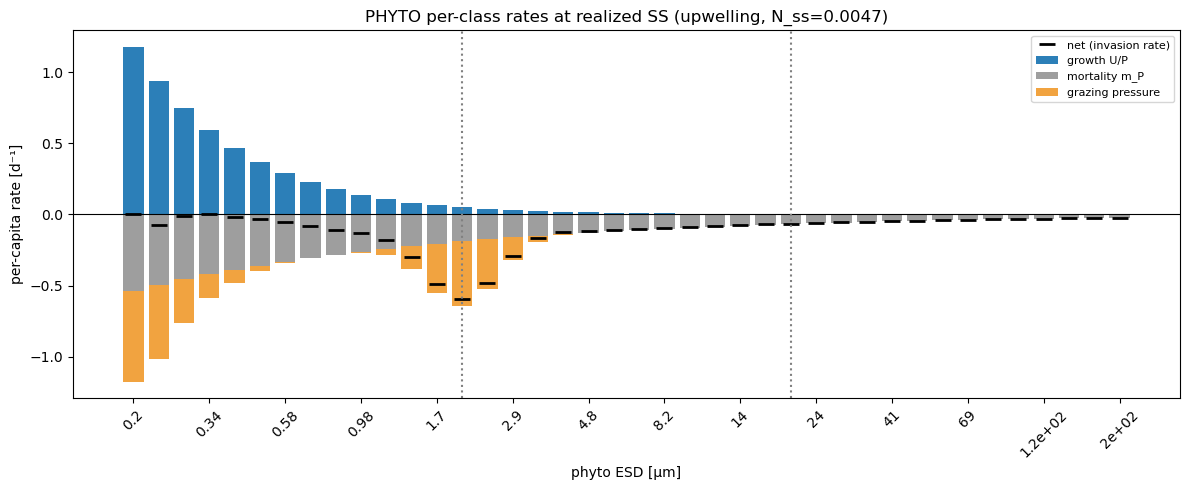

N_ss=0.0047  fT_g=1.16 fT_z=1.31
     ESD   growth    mort   grazeP      net       P_ss
    0.20    1.176   0.536    0.639    0.001   9.71e-02
    0.29    0.746   0.457    0.303   -0.014   9.86e-30
    0.41    0.466   0.390    0.093   -0.017   2.68e-35
    0.58    0.288   0.333    0.010   -0.055  1.05e-101
    0.82    0.176   0.284    0.001   -0.108   0.00e+00
    1.18    0.107   0.242    0.042   -0.177   0.00e+00
    1.68    0.065   0.206    0.348   -0.489   0.00e+00
    2.39    0.039   0.176    0.348   -0.484   0.00e+00
    3.40    0.024   0.150    0.042   -0.169   0.00e+00
    4.85    0.014   0.128    0.001   -0.114   0.00e+00
    6.91    0.008   0.109    0.000   -0.100   0.00e+00
    9.85    0.005   0.093    0.000   -0.088   0.00e+00
   14.03    0.003   0.079    0.000   -0.076  8.94e-138
   20.00    0.002   0.068    0.000   -0.066  1.19e-119
   28.50    0.001   0.058    0.000   -0.056  1.39e-103
   40.62    0.001   0.049    0.000   -0.048   1.58e-89
   57.89    0.000   0.042    0.0

In [6]:
# ── Cell A2 — per-class phyto rates at the realized SS (stacked, flux_plot style) ──
import numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns

REGIME = 'upwelling'; TAIL = 1000
T = targets[REGIME]['forcing'].get('Temperature__value', cns.T_DEFAULT)
P  = np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values)
Z  = np.asarray(out['Zooplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values)
Nss = float(np.asarray(out['Nutrient__value'].isel(time=slice(-TAIL,None)).mean('time').values))

pe = cns.phyto_esd; n = cns.N_CLASSES
mu, ks, mP = cns.mu_max_arr, cns.ks_arr, cns.mP_arr
Imax, KsZ, phi = cns.Imax_arr, cns.KsZ_arr, cns.phiPZ_omni
fTg = cns.Q10_GROW**((T-cns.T_REF)/10); fTz = cns.Q10_GRAZE**((T-cns.T_REF)/10)

growth_pc = fTg * mu * Nss/(Nss+ks)            # per-capita growth at SS N [d-1]
mort_pc   = mP                                  # per-capita mortality (=0.1*mu_max)
B = np.concatenate([P, Z]); S = (phi*B[:,None]).sum(axis=0)
graze_pc = (fTz*Imax[None,:]*Z[None,:]*phi*(S/(S**2+KsZ**2))[None,:]).sum(axis=1)[:n]  # pressure on each phyto class
net_pc = growth_pc - mort_pc - graze_pc

fig, ax = plt.subplots(figsize=(12,5)); x = np.arange(n)
ax.bar(x, growth_pc, color='#2c7fb8', label='growth U/P')
ax.bar(x, -mort_pc, color='#9e9e9e', label='mortality m_P')
ax.bar(x, -graze_pc, bottom=-mort_pc, color='#f1a340', label='grazing pressure')
ax.plot(x, net_pc, 'k_', ms=12, mew=2, label='net (invasion rate)')
ax.axhline(0, c='k', lw=0.8)
for b in (2, 20): ax.axvline(np.interp(np.log10(b), np.log10(pe), x), c='grey', ls=':')
ax.set_xticks(x[::3]); ax.set_xticklabels([f'{e:.2g}' for e in pe[::3]], rotation=45)
ax.set_xlabel('phyto ESD [µm]'); ax.set_ylabel('per-capita rate [d⁻¹]')
ax.set_title(f'PHYTO per-class rates at realized SS ({REGIME}, N_ss={Nss:.4f})'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"N_ss={Nss:.4f}  fT_g={fTg:.2f} fT_z={fTz:.2f}")
print(f"{'ESD':>8}{'growth':>9}{'mort':>8}{'grazeP':>9}{'net':>9}{'P_ss':>11}")
for i in range(0, n, 2):
    print(f"{pe[i]:8.2f}{growth_pc[i]:9.3f}{mort_pc[i]:8.3f}{graze_pc[i]:9.3f}{net_pc[i]:9.3f}{P[i]:11.2e}")

In [5]:
# ── Cell B — N/P/Z/D gains/losses budget at the tail ──
import numpy as np
REGIME = 'upwelling'; TAIL = 1000
out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd,
                          scan_params={}, fixed_overrides=targets[REGIME]['forcing'])

_missing = []
def tm(name):
    if name not in out.data_vars:
        _missing.append(name); return 0.0
    da = out[name]
    if 'time' in da.dims:
        da = da.isel(time=slice(-TAIL, None)).mean('time')
    v = np.asarray(da.values)
    return float(v.sum()) if v.ndim else float(v)

supply = tm('Inflow__input_value');           uptake = tm('Growth__uptake_value')
gloss_P = tm('GrazingRouter__loss_P_value');   gain_Z = tm('GrazingRouter__gain_Z_value')
gloss_Z = tm('GrazingRouter__loss_Z_value');   egest_D = tm('GrazingRouter__egestion_to_D_value')
excr_N  = tm('GrazingRouter__excretion_to_N_value')
mP_tot = tm('PhytoMortality__mortality_value'); mP_D = tm('PhytoMortality__mortality_to_D_value'); mP_N = tm('PhytoMortality__mortality_to_N_value')
mZl_tot = tm('ZooLinMortality__mortality_value'); mZl_D = tm('ZooLinMortality__mortality_to_D_value'); mZl_N = tm('ZooLinMortality__mortality_to_N_value')
mZq_tot = tm('ZooQuadMortality__mortality_value'); mZq_D = tm('ZooQuadMortality__mortality_to_D_value'); mZq_N = tm('ZooQuadMortality__mortality_to_N_value')
remin = tm('DetritusRemin__remineralization_value'); sink = tm('DetritusSink__sinking_value')
fish_P = tm('FishGrazing__fish_graze_phyto_value'); fish_Z = tm('FishGrazing__fish_graze_zoo_value')

Npool = tm('Nutrient__value'); Dpool = tm('Detritus__value')
Ppool = float(np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values).sum())
Zpool = float(np.asarray(out['Zooplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values).sum())

exp_mZq = mZq_tot - mZq_D - mZq_N      # routed-out fractions that leave the system
exp_mZl = mZl_tot - mZl_D - mZl_N
exp_mP  = mP_tot  - mP_D  - mP_N
export_tot = sink + exp_mZq + exp_mZl + exp_mP + fish_P + fish_Z

def line(tag, gains, losses):
    g = "  ".join(f"+{k} {v:.3e}" for k, v in gains); l = "  ".join(f"-{k} {v:.3e}" for k, v in losses)
    net = sum(v for _, v in gains) - sum(v for _, v in losses)
    print(f"{tag}: net={net:+.2e}\n   {g}\n   {l}")

print(f"=== N/P/Z/D budget [{REGIME}] tail-mean [mmol N m-3 d-1] ===")
print(f"pools: N={Npool:.3e}  ΣP={Ppool:.3e}  ΣZ={Zpool:.3e}  D={Dpool:.3e}")
line('N', [('supply',supply),('excr',excr_N),('Pmort→N',mP_N),('Zlin→N',mZl_N),('Zquad→N',mZq_N),('remin',remin)], [('uptake',uptake)])
line('P', [('uptake',uptake)], [('graze',gloss_P),('mort',mP_tot),('fish',fish_P)])
line('Z', [('assim',gain_Z)], [('graze',gloss_Z),('quad',mZq_tot),('lin',mZl_tot),('fish',fish_Z)])
line('D', [('egest',egest_D),('Pmort→D',mP_D),('Zlin→D',mZl_D),('Zquad→D',mZq_D)], [('remin',remin),('sink',sink)])
print(f"EXPORT total={export_tot:.3e}  ( sink={sink:.2e}  Zquad_exp={exp_mZq:.2e}  fish={fish_P+fish_Z:.2e} )")
print(f"supply={supply:.3e}  → export/supply = {export_tot/max(supply,1e-30):.2f}  (≈1 at steady state)")
if _missing: print("MISSING vars (paste list(out.data_vars) and I'll fix names):", _missing)

=== N/P/Z/D budget [upwelling] tail-mean [mmol N m-3 d-1] ===
pools: N=4.685e-03  ΣP=1.297e-01  ΣZ=1.015e-01  D=5.114e-01
N: net=-6.00e-09
   +supply 6.026e-02  +excr 1.535e-02  +Pmort→N 6.585e-03  +Zlin→N 0.000e+00  +Zquad→N 0.000e+00  +remin 5.114e-02
   -uptake 1.333e-01
P: net=+6.50e-09
   +uptake 1.333e-01
   -graze 6.748e-02  -mort 6.585e-02  -fish 0.000e+00
Z: net=-9.45e-11
   +assim 2.046e-02
   -graze 1.436e-02  -quad 1.029e-03  -lin 5.073e-03  -fish 0.000e+00
D: net=-3.93e-10
   +egest 4.604e-02  +Pmort→D 5.926e-02  +Zlin→D 5.073e-03  +Zquad→D 5.147e-04
   -remin 5.114e-02  -sink 5.975e-02
EXPORT total=6.026e-02  ( sink=5.97e-02  Zquad_exp=5.15e-04  fish=0.00e+00 )
supply=6.026e-02  → export/supply = 1.00  (≈1 at steady state)


In [7]:
# ── Cell C — DIAGNOSTIC: phyto mortality sweep (is m_P the binding constraint?) ──
import numpy as np
REGIME = 'upwelling'; TAIL = 1000
n = cns.N_CLASSES; forcing = targets[REGIME]['forcing']

variants = {'Banas 0.1*umax (base)': cns.mP_arr,
            'uniform 0.10': np.full(n, 0.10),
            'uniform 0.05': np.full(n, 0.05),
            'Ward 0.02':    np.full(n, 0.02),
            'Tani 0.0015':  np.full(n, 0.0015)}

print(f"[m_P sweep | {REGIME} | F_N={forcing['Inflow__FN']:.2f}]")
print(f"{'m_P':>22}{'CV':>7}{'mcs':>7}{'Pico':>7}{'Nano':>7}{'Micro':>7}{'N_ss':>9}{'SumP':>9}")
for lab, mP in variants.items():
    out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd, scan_params={},
                              fixed_overrides={**forcing, 'PhytoMortality__rate': mP})
    proc = pu.process_regime_run(out, cns.phyto_esd, cns.zoo_esd, bin_defs, tail_len=TAIL)
    pb = np.asarray(proc['phyto_bins_tail'])
    fr = np.nanmedian(pb/np.clip(pb.sum(0, keepdims=True), 1e-12, None), axis=1)
    Nss = float(np.asarray(out['Nutrient__value'].isel(time=slice(-TAIL,None)).mean('time').values))
    SP  = float(np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-TAIL,None)).mean('time').values).sum())
    print(f"{lab:>22}{proc['cv']:7.2f}{np.nanmedian(proc['mcs_tail']):7.2f}"
          f"{fr[0]:7.2f}{fr[1]:7.2f}{fr[2]:7.2f}{Nss:9.4f}{SP:9.3f}")

[m_P sweep | upwelling | F_N=2.58]
                   m_P     CV    mcs   Pico   Nano  Micro     N_ss     SumP
 Banas 0.1*umax (base)   0.00   0.63   1.00   0.00   0.00   0.0047    0.130
          uniform 0.10   0.01   0.63   1.00   0.00   0.00   0.0038    0.193
          uniform 0.05   0.00   0.63   1.00   0.00   0.00   0.0037    0.212
             Ward 0.02   0.01   0.63   1.00   0.00   0.00   0.0037    0.215
           Tani 0.0015   0.01   1.06   0.77   0.22   0.00   0.0036    0.285


In [8]:
# ── Cell D — OVERNIGHT comprehensive OFAT size-spectrum sweep (NPZD baseline) ──
import numpy as np, time, pandas as pd
from cariaco_npzd_comps import compute_grazing_kernel

REGIMES = ('upwelling',)        # add 'relaxed' for a fuller (~2x longer) run
TAIL = 1000
n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
Imax0, mP0 = cns.Imax_arr, cns.mP_arr
kern = lambda s, th: compute_grazing_kernel(pe, ze, mode='omni', theta_opt=th, sigma_log=s, convention='mattern')

def specs_for():
    S = []
    # ---- GROWTH (Banas base: μ=2.6·s^-0.45, K_s=0.1·s^1.0, m_P=0.1·μmax) ----
    S += [('mu_exp',    [(f'{e:+.2f}', {'Growth__mu_max': 2.6*pe**e})      for e in (-0.45,-0.30,-0.16,0.0)])]
    S += [('mu_pref',   [(f'{a:.2f}',  {'Growth__mu_max': a*pe**-0.45})     for a in (1.0,2.6,4.19)])]
    S += [('ks_exp',    [(f'{e:.2f}',  {'Growth__halfsat': 0.1*pe**e})      for e in (0.48,0.81,1.0)])]
    S += [('ks_source', [('Banas .1s^1', {'Growth__halfsat':0.1*pe**1.0}),
                         ('Ward .143s^.81',{'Growth__halfsat':0.143*pe**0.81}),
                         ('Tani .33s^.48',{'Growth__halfsat':0.33*pe**0.48})])]
    S += [('m_P',       [(f'{m:.4g}',  {'PhytoMortality__rate': np.full(n,m)}) for m in (0.0015,0.02,0.05,0.1)]
                        + [('Banas .1umax', {'PhytoMortality__rate': mP0})])]
    # ---- GRAZING (Dutkiewicz base: g_max piecewise, K_sZ=0.23, σ=0.15, θ=10) ----
    S += [('K_sZ',      [(f'{k:.2f}',  {'Grazing__KsZ': np.full(n,k)})      for k in (0.05,0.15,0.23,0.45,1.0,3.0)])]
    S += [('Imax_x',    [(f'x{m:.1f}', {'Grazing__Imax': m*Imax0})          for m in (0.5,1.0,2.0,4.0)])]
    S += [('sigma',     [(f'{s:.2f}',  {'Grazing__phiPZ': kern(s,10.0)})    for s in (0.10,0.15,0.25,0.40)])]
    S += [('theta*',    [(f'{t:.0f}',  {'Grazing__phiPZ': kern(0.15,t)})    for t in (5,8,10,15)])]    # *structural
    S += [('GGE*',      [(f'{g:.2f}',  {'GrazingRouter__gge': g})           for g in (0.10,0.25,0.40)])] # *rejected-as-lever; diagnostic
    # ---- CLOSURE ----
    S += [('m_Z',       [(f'{m:.2f}',  {'ZooQuadMortality__rate': m})       for m in (0.05,0.1,0.2,0.5)])]
    S += [('m_Zlin',    [(f'{m:.3f}',  {'ZooLinMortality__rate': m})        for m in (0.0,0.05,0.1,0.2)])]
    # ---- DETRITUS / ROUTING ----
    S += [('w_sink',    [(f'{w:.0f}',  {'DetritusSink__w_sink': float(w)})  for w in (1,5,10,20)])]
    S += [('k_remin',   [(f'{k:.2f}',  {'DetritusRemin__k_remin': k})       for k in (0.05,0.1,0.3)])]
    S += [('Zquad_fracD',[(f'D{d:.2f}',{'ZooQuadMortality__frac_D':d,'ZooQuadMortality__frac_export':1.0-d}) for d in (0.0,0.5,1.0)])]
    S += [('Pmort_fracD',[(f'D{d:.2f}',{'PhytoMortality__frac_D':d,'PhytoMortality__frac_export':0.0}) for d in (0.0,0.5,0.9)])]
    # ---- PHYSICAL / FORCING ----
    S += [('F_N',       [(f'{f:.1f}',  {'Inflow__FN': float(f)})            for f in (1,2.58,5,10,15,25)])]  # high F_N may limit-cycle
    S += [('d_e',       [(f'{d:.0f}',  {'Inflow__de': float(d)})            for d in (30,43,55)])]           # broadcast: supply + sinking
    S += [('Temp',      [(f'{t:.0f}',  {'Temperature__value': float(t)})    for t in (18,23,28)])]
    S += [('r_fish',    [(f'{r:.3f}',  {'FishGrazing__rate': r})            for r in (0.0,0.01,0.05)])]      # likely inert w/o large Z
    return S

def run_one(base, ovr):
    out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_slim, scan_params={},
                              fixed_overrides={**base, **ovr})
    proc = pu.process_regime_run(out, pe, ze, bin_defs, tail_len=TAIL)
    pb = np.asarray(proc['phyto_bins_tail'])
    fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None), axis=1)
    tm = lambda nm: float(np.asarray(out[nm].isel(time=slice(-TAIL,None)).mean('time').values).sum())
    return proc['cv'], float(np.nanmedian(proc['mcs_tail'])), fr, tm('Nutrient__value'), tm('Phytoplankton__biomass'), tm('Zooplankton__biomass')

rows, t0 = [], time.time()
for REGIME in REGIMES:
    base = dict(targets[REGIME]['forcing'])
    print(f"\n############  REGIME = {REGIME}  (F_N={base['Inflow__FN']:.2f}, d_e={base['Inflow__de']:.1f})  ############")
    for tag, vals in specs_for():
        print(f"\n=== {tag} ===  {'value':>14}{'CV':>6}{'mcs':>6}{'Pico':>6}{'Nano':>6}{'Micro':>6}{'N_ss':>8}{'SumP':>7}{'SumZ':>7}")
        for vlab, ovr in vals:
            try:
                cv, mcs, fr, Nss, SP, SZ = run_one(base, ovr)
                print(f"{'':>14}{vlab:>14}{cv:6.2f}{mcs:6.2f}{fr[0]:6.2f}{fr[1]:6.2f}{fr[2]:6.2f}{Nss:8.4f}{SP:7.3f}{SZ:7.3f}")
                rows.append((REGIME,tag,vlab,cv,mcs,fr[0],fr[1],fr[2],Nss,SP,SZ))
            except Exception as e:
                print(f"{'':>14}{vlab:>14}   FAILED: {type(e).__name__}: {e}")
                rows.append((REGIME,tag,vlab,*([np.nan]*8)))
        pd.DataFrame(rows, columns=['regime','param','value','CV','mcs','Pico','Nano','Micro','N_ss','SumP','SumZ']).to_csv('npzd_ofat_sweep.csv', index=False)
        print(f"    [elapsed {time.time()-t0:.0f}s, {len(rows)} runs → npzd_ofat_sweep.csv]")
print(f"\nDONE — {len(rows)} runs in {(time.time()-t0)/60:.0f} min → npzd_ofat_sweep.csv")


############  REGIME = upwelling  (F_N=2.58, d_e=42.8)  ############

=== mu_exp ===           value    CV   mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                       -0.45  0.00  0.63  1.00  0.00  0.00  0.0047  0.130  0.101
                       -0.30  0.00  0.63  1.00  0.00  0.00  0.0062  0.136  0.104
                       -0.16  0.00  0.63  1.00  0.00  0.00  0.0082  0.147  0.109
                       +0.00  0.00  0.63  1.00  0.00  0.00  0.0112  0.166  0.117
    [elapsed 237s, 4 runs → npzd_ofat_sweep.csv]

=== mu_pref ===           value    CV   mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                        1.00  0.01  0.63  1.00  0.00  0.00  0.0187  0.138  0.106
                        2.60  0.00  0.63  1.00  0.00  0.00  0.0047  0.130  0.101


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 531626 RHS evaluations for 5000 output points (106/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)


                        4.19  0.00  0.63  1.00  0.00  0.00  0.0027  0.130  0.100
    [elapsed 547s, 7 runs → npzd_ofat_sweep.csv]

=== ks_exp ===           value    CV   mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                        0.48  0.01  0.63  1.00  0.00  0.00  0.0101  0.158  0.112
                        0.81  0.00  0.63  1.00  0.00  0.00  0.0063  0.136  0.103
                        1.00  0.00  0.63  1.00  0.00  0.00  0.0047  0.130  0.101
    [elapsed 763s, 10 runs → npzd_ofat_sweep.csv]

=== ks_source ===           value    CV   mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                 Banas .1s^1  0.00  0.63  1.00  0.00  0.00  0.0047  0.130  0.101
              Ward .143s^.81  0.00  0.63  1.00  0.00  0.00  0.0089  0.136  0.103
               Tani .33s^.48  0.01  0.63  1.00  0.00  0.00  0.0333  0.158  0.112
    [elapsed 917s, 13 runs → npzd_ofat_sweep.csv]

=== m_P ===           value    CV   mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                      0.0015  0.

In [9]:
# ── Cell E — 2D diagnostic: phyto mortality × F_N (is there ANY bottom-up Micro axis?) ──
import numpy as np
REGIME = 'upwelling'; TAIL = 1000
n = cns.N_CLASSES; base = dict(targets[REGIME]['forcing'])
mP_opts = {'0.0015': np.full(n,0.0015), '0.01': np.full(n,0.01),
           '0.02': np.full(n,0.02), 'Banas .1umax': cns.mP_arr}
FN_opts = [2.58, 5.0, 10.0, 25.0]

print(f"[m_P x F_N | {REGIME}]  cell = Pico/Nano/Micro + CV")
print(f"{'m_P \\\\ F_N':>14} " + " ".join(f"{f:>22.1f}" for f in FN_opts))
for mlab, mP in mP_opts.items():
    cells = []
    for f in FN_opts:
        try:
            out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_slim, scan_params={},
                                      fixed_overrides={**base, 'PhytoMortality__rate': mP, 'Inflow__FN': float(f)})
            proc = pu.process_regime_run(out, cns.phyto_esd, cns.zoo_esd, bin_defs, tail_len=TAIL)
            pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
            cells.append(f"{fr[0]:.2f}/{fr[1]:.2f}/{fr[2]:.2f} cv{proc['cv']:.1f}")
        except Exception as e:
            cells.append(f"FAIL:{type(e).__name__}")
    print(f"{mlab:>14} " + " ".join(f"{c:>22}" for c in cells))

[m_P x F_N | upwelling]  cell = Pico/Nano/Micro + CV
    m_P \\ F_N                    2.6                    5.0                   10.0                   25.0
        0.0015   0.78/0.22/0.00 cv0.0   0.86/0.14/0.00 cv0.0   0.93/0.07/0.00 cv0.0   0.97/0.03/0.00 cv0.0
          0.01   1.00/0.00/0.00 cv0.0   0.88/0.12/0.00 cv0.0   0.96/0.04/0.00 cv0.0   0.98/0.02/0.00 cv0.0
          0.02   1.00/0.00/0.00 cv0.0   1.00/0.00/0.00 cv0.0   1.00/0.00/0.00 cv0.0   1.00/0.00/0.00 cv0.0
  Banas .1umax   1.00/0.00/0.00 cv0.0   1.00/0.00/0.00 cv0.0   1.00/0.00/0.00 cv0.0   1.00/0.00/0.00 cv0.0


In [10]:
# ── Cell F — growth/grazing size-structure consistency test ──
import numpy as np
REGIME = 'upwelling'; TAIL = 1000
n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
base = dict(targets[REGIME]['forcing'])

mu_banas   = 2.6 * pe**-0.45
mu_cap3    = np.where(pe < 3.0, 2.6*3.0**-0.45, mu_banas)         # flat <3µm (mirrors Dutk 30µm-zoo grazing step)
mu_maranon = np.where(pe < 5.38, 0.33*pe**0.57, 1.83*pe**-0.45)   # MS3 Marañón unimodal (prefactors MS3-derived)
ks_banas   = 0.1 * pe**1.0
ks_cap5    = np.where(pe < 5.0, 0.1*5.0, ks_banas)               # flat <5µm (Banas K_s validity floor)
imax_banas = 26.0 * ze**-0.40                                     # monotonic g_max — small zoo graze hardest

variants = {
  'baseline (Banas mu / Dutk graze)': {},
  'cap mu @3um':                      {'Growth__mu_max': mu_cap3},
  'cap mu+Ks (Banas validity)':       {'Growth__mu_max': mu_cap3, 'Growth__halfsat': ks_cap5},
  'Maranon unimodal mu':              {'Growth__mu_max': mu_maranon},
  'Banas monotonic g_max only':       {'Grazing__Imax': imax_banas},
  'cap mu+Ks  +  Banas g_max':        {'Growth__mu_max': mu_cap3, 'Growth__halfsat': ks_cap5, 'Grazing__Imax': imax_banas},
}
for f in [2.58, 10.0]:
    print(f"\n--- F_N={f} ---   {'variant':>34}{'CV':>6}{'mcs':>7}{'Pico':>6}{'Nano':>6}{'Micro':>6}{'N_ss':>8}{'SumP':>7}{'SumZ':>7}")
    for lab, ovr in variants.items():
        try:
            out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_slim, scan_params={},
                                      fixed_overrides={**base, 'Inflow__FN': float(f), **ovr})
            proc = pu.process_regime_run(out, pe, ze, bin_defs, tail_len=TAIL)
            pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
            tm = lambda nm: float(np.asarray(out[nm].isel(time=slice(-TAIL,None)).mean('time').values).sum())
            print(f"{'':>14}{lab:>34}{proc['cv']:6.2f}{np.nanmedian(proc['mcs_tail']):7.2f}"
                  f"{fr[0]:6.2f}{fr[1]:6.2f}{fr[2]:6.2f}{tm('Nutrient__value'):8.4f}{tm('Phytoplankton__biomass'):7.3f}{tm('Zooplankton__biomass'):7.3f}")
        except Exception as e:
            print(f"{'':>14}{lab:>34}   FAILED: {type(e).__name__}: {e}")


--- F_N=2.58 ---                              variant    CV    mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                baseline (Banas mu / Dutk graze)  0.00   0.63  1.00  0.00  0.00  0.0047  0.130  0.101
                                     cap mu @3um  0.00   0.63  1.00  0.00  0.00  0.0254  0.172  0.130
                      cap mu+Ks (Banas validity)  0.00   1.53  0.61  0.39  0.00  0.1747  0.316  0.149
                             Maranon unimodal mu  0.00   4.21  0.32  0.54  0.14  0.9029  0.347  0.222
                      Banas monotonic g_max only  0.00   0.63  1.00  0.00  0.00  0.0072  0.113  0.129
                       cap mu+Ks  +  Banas g_max  0.00   1.60  0.59  0.41  0.00  0.1790  0.309  0.158

--- F_N=10.0 ---                              variant    CV    mcs  Pico  Nano Micro    N_ss   SumP   SumZ
                baseline (Banas mu / Dutk graze)  0.00   0.63  1.00  0.00  0.00  0.0128  0.306  0.284
                                     cap mu @3um  0.00   0.63  1.00  0

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=500.1 on Grazing_grazing[9,6] = -1.38e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_38674/391217250.py:31: RuntimeWarning: All-NaN slice encountered
  print(f"{'':>14}{lab:>34}{proc['cv']:6.2f}{np.nanmedian(proc['mcs_tail']):7.2f}"


                             Maranon unimodal mu   nan    nan   nan   nan   nan     nan    nan    nan
                      Banas monotonic g_max only  0.00   0.63  1.00  0.00  0.00  0.0251  0.242  0.359
                       cap mu+Ks  +  Banas g_max  0.00   1.09  0.76  0.24  0.00  0.6740  0.524  0.411


In [11]:
# ── Cell G — literature growth & grazing allometries vs pico-domination ──
import numpy as np, xso
REGIME = 'upwelling'; TAIL = 1000
n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
base = dict(targets[REGIME]['forcing'])

# Surfaced: RK45 + relaxed atol (project default) but looser instability guard so a
# near-zero class going -1e-6 doesn't NaN the run (the F_N=10 Maranon trip). CV flags real cycles.
setup_G = xso.setup(solver='solve_ivp', model=cns.model_npzd, time=cns.ivp_time_array,
                    input_vars=cns.make_npzd_input_vars(), output_vars=cns.SLIM_OUTPUT_VARS,
                    solver_kwargs={'method':'RK45','atol':1e-6,'rtol':1e-4,'instability_neg_threshold':-1e-3})

mu_maranon = np.where(pe < 5.38, 0.33*pe**0.57, 1.83*pe**-0.45)   # MS3 Marañón unimodal (prefactors MS3-derived)
ks_capped  = np.where(pe < 5.0, 0.5, 0.1*pe**1.0)                 # Banas Ks flat below 5µm validity floor
mu_capped  = np.where(pe < 1.0, 2.6, 2.6*pe**-0.45)              # Banas mu flat below 1µm validity floor

configs = {
  'BASE Banas mu / Dutk graze':   {},
  # --- GRAZING g_max shape (Banas growth fixed; small zoo = small prey) ---
  'g: Banas 26 s^-.40':           {'Grazing__Imax': 26.0*ze**-0.40},
  'g: Taniguchi 34 s^-.66':       {'Grazing__Imax': 33.96*ze**-0.66},   # steepest -> small P hardest
  'g: Ward 24 s^-.48':            {'Grazing__Imax': 24.3*ze**-0.48},
  'g: Dutk UNcapped 34 s^-.48':   {'Grazing__Imax': 34.3*ze**-0.48},    # remove the 9.8 small-zoo cap
  # --- GROWTH mu/Ks (Dutk grazing fixed) ---
  'grow: Ks cap@5um only':        {'Growth__halfsat': ks_capped},
  'grow: mu&Ks cap valid':        {'Growth__mu_max': mu_capped, 'Growth__halfsat': ks_capped},
  'grow: Ward mu/Ks':             {'Growth__mu_max': 4.19*pe**-0.45, 'Growth__halfsat': 0.143*pe**0.81},
  'grow: Taniguchi mu/Ks':        {'Growth__mu_max': 1.36*pe**-0.16, 'Growth__halfsat': 0.33*pe**0.48},
  'grow: Maranon mu':             {'Growth__mu_max': mu_maranon},
  # --- COMBOS (matched growth + grazing size structure) ---
  'combo: mu&Ks cap + Banas g':   {'Growth__mu_max': mu_capped, 'Growth__halfsat': ks_capped, 'Grazing__Imax': 26.0*ze**-0.40},
  'combo: Maranon + Taniguchi g': {'Growth__mu_max': mu_maranon, 'Grazing__Imax': 33.96*ze**-0.66},
}
FN_test = [2.58, 10.0, 25.0]

for lab, ovr in configs.items():
    print(f"{lab:>30}", end='')
    for f in FN_test:
        try:
            out = pu.run_single_point(cns.model_npzd, setup_G, scan_params={},
                      fixed_overrides={**base, 'Inflow__FN': float(f), **ovr})
            proc = pu.process_regime_run(out, pe, ze, bin_defs, tail_len=TAIL)
            pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
            mcs = np.nanmedian(proc['mcs_tail'])
            print(f" | F{f:>4.0f} mcs{mcs:4.1f} P{fr[0]:.2f}N{fr[1]:.2f}M{fr[2]:.2f} cv{proc['cv']:.1f}", end='')
        except Exception as e:
            print(f" | F{f:>4.0f} FAIL", end='')
    print()

    BASE Banas mu / Dutk graze | F   3 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  10 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  25 mcs 0.6 P1.00N0.00M0.00 cv0.0
            g: Banas 26 s^-.40 | F   3 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  10 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  25 mcs 0.6 P1.00N0.00M0.00 cv0.0
        g: Taniguchi 34 s^-.66 | F   3 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  10 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  25 mcs 0.6 P1.00N0.00M0.00 cv0.0
             g: Ward 24 s^-.48 | F   3 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  10 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  25 mcs 0.6 P1.00N0.00M0.00 cv0.0
    g: Dutk UNcapped 34 s^-.48 | F   3 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  10 mcs 0.6 P1.00N0.00M0.00 cv0.0 | F  25 mcs 0.6 P1.00N0.00M0.00 cv0.0
         grow: Ks cap@5um only | F   3 mcs 1.0 P0.82N0.18M0.00 cv0.0 | F  10 mcs 0.7 P0.94N0.06M0.00 cv0.0 | F  25 mcs 0.6 P0.99N0.01M0.00 cv0.0
         grow: mu&Ks cap valid | F   3 mcs 1.2 P0.73N0.27M0.00 cv0.0 | F  10 mcs 0.9 P0.90N0.06M0.04 cv0.0 | F  25 mcs 1.0 P0.89N0

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=190.9 on P[18] = -0.00111. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


 | F  25 mcs nan PnanNnanMnan cvnan


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_38674/2600040170.py:44: RuntimeWarning: All-NaN slice encountered
  mcs = np.nanmedian(proc['mcs_tail'])


In [12]:
# ── Cell H — candidate growth allometries vs obs (regime contrast + F_N sweep) ──
import numpy as np
TAIL = 1000; n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
mu_maranon = np.where(pe < 5.38, 0.33*pe**0.57, 1.83*pe**-0.45)
candidates = {
  'Banas (base)':    {},
  'Taniguchi mu/Ks': {'Growth__mu_max':1.36*pe**-0.16, 'Growth__halfsat':0.33*pe**0.48},
  'Maranon mu':      {'Growth__mu_max': mu_maranon},
}
def run(forcing, ovr, fn=None):
    f = dict(forcing)
    if fn is not None: f['Inflow__FN'] = float(fn)
    out = pu.run_single_point(cns.model_npzd, setup_G, scan_params={}, fixed_overrides={**f, **ovr})
    proc = pu.process_regime_run(out, pe, ze, bin_defs, tail_len=TAIL)
    pb = np.asarray(proc['phyto_bins_tail']); fr = np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
    return np.nanmedian(proc['mcs_tail']), fr, proc['cv']

print("REGIME CONTRAST  (obs: upwelling mcs~5.5 Micro-lean / relaxed mcs~2.0 Pico)")
for lab, ovr in candidates.items():
    print(f"  {lab:>16}", end='')
    for reg in ('upwelling','relaxed'):
        mcs, fr, cv = run(targets[reg]['forcing'], ovr)
        print(f" | {reg[:3]} mcs{mcs:5.1f} P{fr[0]:.2f}N{fr[1]:.2f}M{fr[2]:.2f} cv{cv:.1f}", end='')
    print()

print("\nF_N SWEEP (upwelling d_e)  mcs vs F_N:")
for lab, ovr in candidates.items():
    base = dict(targets['upwelling']['forcing'])
    print(f"  {lab:>16}: " + "  ".join(f"F{fn:>4.1f}>{run(base, ovr, fn)[0]:4.1f}" for fn in (1,2.58,5,10,15,25)))

REGIME CONTRAST  (obs: upwelling mcs~5.5 Micro-lean / relaxed mcs~2.0 Pico)
      Banas (base) | upw mcs  0.6 P1.00N0.00M0.00 cv0.0 | rel mcs  0.6 P1.00N0.00M0.00 cv0.0
   Taniguchi mu/Ks | upw mcs  3.0 P0.51N0.29M0.20 cv0.0 | rel mcs  0.9 P0.85N0.15M0.00 cv0.0
        Maranon mu | upw mcs  4.2 P0.32N0.54M0.14 cv0.0 | rel mcs  3.5 P0.32N0.63M0.06 cv0.0

F_N SWEEP (upwelling d_e)  mcs vs F_N:
      Banas (base): F 1.0> 0.6  F 2.6> 0.6  F 5.0> 0.6  F10.0> 0.6  F15.0> 0.6  F25.0> 0.6
   Taniguchi mu/Ks: F 1.0> 0.6  F 2.6> 3.0  F 5.0> 8.8  F10.0> 6.0  F15.0> 5.0  F25.0> 4.4
        Maranon mu: F 1.0> 3.6  F 2.6> 4.2  F 5.0> 6.3  F10.0> 7.4  F15.0> 7.5  F25.0> 7.6


In [13]:
# ── Cell I — bimodality / edge-case scan: growth base × diatom lever × F_N ──
import numpy as np
TAIL=1000; n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
mu_tani=1.36*pe**-0.16; ks_tani=0.33*pe**0.48
mu_mar =np.where(pe<5.38, 0.33*pe**0.57, 1.83*pe**-0.45)
ks_cap =np.where(pe<5.0, 0.5, 0.1*pe**1.0)
phi0   =cns.phiPZ_omni.copy()

def shield(sP):                                   # palatability of Micro (>20µm) phyto x (1-sP)
    k=phi0.copy(); m=np.zeros(2*n,bool); m[:n]=pe>20.0; k[m,:]*=(1.0-sP); return k
def boost(mu_arr,b):                              # diatom growth boost on Micro (>20µm)
    a=mu_arr.copy(); a[pe>20.0]*=b; return a

bases = {
  'Taniguchi':   {'Growth__mu_max':mu_tani,'Growth__halfsat':ks_tani},
  'Maranon':     {'Growth__mu_max':mu_mar},
  'Banas+Kscap': {'Growth__halfsat':ks_cap},
}
levers = {
  'none':         lambda ov: ov,
  'boostx3':      lambda ov: {**ov,'Growth__mu_max':boost(ov.get('Growth__mu_max',2.6*pe**-0.45),3.0)},
  'shield0.3':    lambda ov: {**ov,'Grazing__phiPZ':shield(0.3)},
  'boost+shield': lambda ov: {**ov,'Growth__mu_max':boost(ov.get('Growth__mu_max',2.6*pe**-0.45),3.0),'Grazing__phiPZ':shield(0.3)},
}
def metrics(forcing,ovr):
    out=pu.run_single_point(cns.model_npzd,setup_G,scan_params={},fixed_overrides={**forcing,**ovr})
    proc=pu.process_regime_run(out,pe,ze,bin_defs,tail_len=TAIL)
    Ps=np.asarray(proc['Pspec']); alive=Ps>0.01*Ps.max(); nco=int(alive.sum()); rng=pe[alive]
    pb=np.asarray(proc['phyto_bins_tail']); fr=np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
    dom='Pico' if fr[0]==max(fr) else ('Micro' if fr[2]==max(fr) else 'NANO')
    bim='BIMODAL' if (fr[1]<fr[0] and fr[1]<fr[2]) else ''
    return nco,(rng.min() if len(rng) else np.nan,rng.max() if len(rng) else np.nan),fr,np.nanmedian(proc['mcs_tail']),proc['cv'],dom,bim

for FN in (2.58,10.0):
    print(f"\n===== F_N={FN} (upwelling d_e) =====")
    print(f"{'base':>12} {'lever':>13} {'ncl':>3} {'ESD span':>13} {'Pi':>4}{'Na':>5}{'Mi':>5} {'mcs':>5} {'cv':>5}  shape")
    bf={**dict(targets['upwelling']['forcing']),'Inflow__FN':float(FN)}
    for blab,bov in bases.items():
        for llab,lf in levers.items():
            try:
                nco,rng,fr,mcs,cv,dom,bim=metrics(bf,lf(dict(bov)))
                print(f"{blab:>12} {llab:>13} {nco:>3} {rng[0]:5.1f}-{rng[1]:5.0f}um {fr[0]:4.2f}{fr[1]:5.2f}{fr[2]:5.2f} {mcs:5.1f} {cv:5.2f}  {dom} {bim}")
            except Exception as e:
                print(f"{blab:>12} {llab:>13}   FAIL:{type(e).__name__}")


===== F_N=2.58 (upwelling d_e) =====
        base         lever ncl      ESD span   Pi   Na   Mi   mcs    cv  shape
   Taniguchi          none  23   0.2-   41um 0.51 0.29 0.20   3.0  0.01  Pico 
   Taniguchi       boostx3  27   0.2-  200um 0.24 0.20 0.56  13.3  0.00  Micro BIMODAL
   Taniguchi     shield0.3  22   0.2-   41um 0.44 0.27 0.29   4.4  0.01  Pico BIMODAL
   Taniguchi  boost+shield  24   0.2-  200um 0.19 0.14 0.66  18.5  0.00  Micro BIMODAL
     Maranon          none  19   1.0-   48um 0.32 0.54 0.14   4.2  0.00  NANO 
     Maranon       boostx3  17   1.0-   98um 0.21 0.48 0.30   7.8  0.01  NANO 
     Maranon     shield0.3  14   1.0-   41um 0.30 0.51 0.19   4.8  0.00  NANO 
     Maranon  boost+shield  15   1.0-   82um 0.19 0.45 0.36   9.2  0.01  NANO 
 Banas+Kscap          none  13   0.2-    7um 0.82 0.18 0.00   1.0  0.01  Pico 
 Banas+Kscap       boostx3  15   0.2-   20um 0.66 0.25 0.09   1.7  0.00  Pico 
 Banas+Kscap     shield0.3  13   0.2-    7um 0.82 0.18 0.00   1.0  0.0

In [15]:
# ── Cell J — Taniguchi growth vs obs swing (regime contrast + full F_N sweep) ──
import numpy as np
TAIL=1000; n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
mu_tani=1.36*pe**-0.16; ks_tani=0.33*pe**0.48
def boost(b): a=mu_tani.copy(); a[pe>20.0]*=b; return a
variants = {
  'Taniguchi':          {'Growth__mu_max':mu_tani,'Growth__halfsat':ks_tani},
  'Taniguchi +boostx2': {'Growth__mu_max':boost(2.0),'Growth__halfsat':ks_tani},
}
def m(forcing,ovr,fn=None):
    f=dict(forcing)
    if fn is not None: f['Inflow__FN']=float(fn)
    out=pu.run_single_point(cns.model_npzd,setup_G,scan_params={},fixed_overrides={**f,**ovr})
    proc=pu.process_regime_run(out,pe,ze,bin_defs,tail_len=TAIL)
    Ps=np.asarray(proc['Pspec']); nco=int((Ps>0.01*Ps.max()).sum())
    pb=np.asarray(proc['phyto_bins_tail']); fr=np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
    dom='Pi' if fr[0]==max(fr) else ('Mi' if fr[2]==max(fr) else 'NA')
    return np.nanmedian(proc['mcs_tail']),fr,proc['cv'],nco,dom

print("REGIME CONTRAST (obs: relaxed mcs~2.0 Pico / upwelling mcs~5.5 Micro-lean ~0.40 Micro)")
for lab,ov in variants.items():
    print(f"  {lab:>18}", end='')
    for reg in ('relaxed','upwelling'):
        mcs,fr,cv,nco,dom=m(targets[reg]['forcing'],ov)
        print(f" | {reg[:3]} mcs{mcs:5.1f} P{fr[0]:.2f}N{fr[1]:.2f}M{fr[2]:.2f} {dom} n{nco} cv{cv:.1f}",end='')
    print()
print("\nF_N SWEEP (upwelling d_e) — does the dominant bin swing Pico->Micro?")
for lab,ov in variants.items():
    print(f"  {lab}")
    base=dict(targets['upwelling']['forcing'])
    for fn in [1,2,3,5,8,12,18,25]:
        mcs,fr,cv,nco,dom=m(base,ov,fn)
        print(f"     F_N{fn:>5}: mcs{mcs:5.1f} P{fr[0]:.2f}N{fr[1]:.2f}M{fr[2]:.2f} {dom} cv{cv:.2f}")

REGIME CONTRAST (obs: relaxed mcs~2.0 Pico / upwelling mcs~5.5 Micro-lean ~0.40 Micro)
           Taniguchi | rel mcs  0.9 P0.85N0.15M0.00 Pi n11 cv0.0 | upw mcs  3.0 P0.51N0.29M0.20 Pi n23 cv0.0
  Taniguchi +boostx2 | rel mcs 13.1 P0.31N0.06M0.63 Mi n21 cv0.0 | upw mcs 12.9 P0.25N0.19M0.56 Mi n30 cv0.0

F_N SWEEP (upwelling d_e) — does the dominant bin swing Pico->Micro?
  Taniguchi
     F_N    1: mcs  0.6 P1.00N0.00M0.00 Pi cv0.01
     F_N    2: mcs  1.5 P0.63N0.37M0.00 Pi cv0.00
     F_N    3: mcs  4.8 P0.44N0.23M0.33 Pi cv0.01
     F_N    5: mcs  8.8 P0.36N0.14M0.50 Mi cv0.01
     F_N    8: mcs  6.8 P0.40N0.16M0.43 Mi cv0.00
     F_N   12: mcs  5.5 P0.43N0.19M0.37 Pi cv0.00
     F_N   18: mcs  4.7 P0.44N0.24M0.32 Pi cv0.00
     F_N   25: mcs  4.4 P0.43N0.29M0.27 Pi cv0.00
  Taniguchi +boostx2
     F_N    1: mcs 13.3 P0.29N0.09M0.62 Mi cv0.02
     F_N    2: mcs 14.8 P0.25N0.13M0.62 Mi cv0.00
     F_N    3: mcs 12.1 P0.26N0.20M0.54 Mi cv0.00
     F_N    5: mcs  9.6 P0.30N0.21M0.48 Mi

In [16]:
# ── Cell K — Taniguchi growth with CONSISTENT mortality (resolve the source mix) ──
import numpy as np
TAIL=1000; n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
mu_tani=1.36*pe**-0.16; ks_tani=0.33*pe**0.48
mort = {
  'm_P=0.1*Banas-mu (mixed, prev test)':    cns.mP_arr,
  'm_P=0.1*Tani-mu (consistent 10% rule)':  0.1*mu_tani,
  'm_P=Tani Lambda 0.0015 uniform':         np.full(n, 0.0015),
}
def m(forcing, mP, fn=None):
    f=dict(forcing)
    if fn is not None: f['Inflow__FN']=float(fn)
    out=pu.run_single_point(cns.model_npzd,setup_G,scan_params={},
          fixed_overrides={**f,'Growth__mu_max':mu_tani,'Growth__halfsat':ks_tani,'PhytoMortality__rate':mP})
    proc=pu.process_regime_run(out,pe,ze,bin_defs,tail_len=TAIL)
    Ps=np.asarray(proc['Pspec']); nco=int((Ps>0.01*Ps.max()).sum())
    pb=np.asarray(proc['phyto_bins_tail']); fr=np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
    dom='Pi' if fr[0]==max(fr) else ('Mi' if fr[2]==max(fr) else 'NA')
    bim='BIMODAL' if (fr[1]<fr[0] and fr[1]<fr[2]) else ''
    return np.nanmedian(proc['mcs_tail']),fr,proc['cv'],nco,dom,bim

print("TANIGUCHI GROWTH x mortality source  (grazing = Dutkiewicz, the intended split)")
for reg in ('relaxed','upwelling'):
    print(f"\n-- {reg} (own forcing) --")
    for lab, mP in mort.items():
        mcs,fr,cv,nco,dom,bim=m(targets[reg]['forcing'],mP)
        print(f"  {lab:>38}: mcs{mcs:5.1f} P{fr[0]:.2f}N{fr[1]:.2f}M{fr[2]:.2f} {dom} n{nco} cv{cv:.2f} {bim}")
print("\n-- upwelling d_e, F_N=10 (bloom) --")
for lab, mP in mort.items():
    mcs,fr,cv,nco,dom,bim=m(targets['upwelling']['forcing'],mP,10.0)
    print(f"  {lab:>38}: mcs{mcs:5.1f} P{fr[0]:.2f}N{fr[1]:.2f}M{fr[2]:.2f} {dom} n{nco} cv{cv:.2f} {bim}")

TANIGUCHI GROWTH x mortality source  (grazing = Dutkiewicz, the intended split)

-- relaxed (own forcing) --
     m_P=0.1*Banas-mu (mixed, prev test): mcs  0.9 P0.85N0.15M0.00 Pi n11 cv0.00 
   m_P=0.1*Tani-mu (consistent 10% rule): mcs  0.7 P0.97N0.03M0.00 Pi n9 cv0.00 
          m_P=Tani Lambda 0.0015 uniform: mcs 10.5 P0.31N0.16M0.53 Mi n30 cv0.00 BIMODAL

-- upwelling (own forcing) --
     m_P=0.1*Banas-mu (mixed, prev test): mcs  3.0 P0.51N0.29M0.20 Pi n23 cv0.01 
   m_P=0.1*Tani-mu (consistent 10% rule): mcs  0.8 P0.87N0.13M0.00 Pi n10 cv0.00 
          m_P=Tani Lambda 0.0015 uniform: mcs  9.0 P0.35N0.15M0.50 Mi n27 cv0.00 BIMODAL

-- upwelling d_e, F_N=10 (bloom) --
     m_P=0.1*Banas-mu (mixed, prev test): mcs  6.0 P0.42N0.18M0.40 Pi n30 cv0.00 BIMODAL
   m_P=0.1*Tani-mu (consistent 10% rule): mcs  4.8 P0.51N0.11M0.39 Pi n28 cv0.01 BIMODAL
          m_P=Tani Lambda 0.0015 uniform: mcs  5.3 P0.46N0.16M0.38 Pi n28 cv0.00 BIMODAL


In [17]:
# ── Cell L — Taniguchi hump investigation: fine F_N sweep + N_ss + small boosts ──
import numpy as np
TAIL=1000; n, pe, ze = cns.N_CLASSES, cns.phyto_esd, cns.zoo_esd
mu_tani=1.36*pe**-0.16; ks_tani=0.33*pe**0.48
def boost(b): a=mu_tani.copy(); a[pe>20.0]*=b; return a
variants={'Taniguchi':mu_tani, 'boost x1.3':boost(1.3), 'boost x1.6':boost(1.6)}
base=dict(targets['upwelling']['forcing'])
for lab,mu in variants.items():
    print(f"\n{lab}:   {'F_N':>5}{'mcs':>6}{'Pi':>5}{'Na':>5}{'Mi':>5}{'N_ss':>8}{'ncl':>4}{'cv':>6}")
    for fn in [1,2,3,4,5,6,8,10,14,20,30]:
        out=pu.run_single_point(cns.model_npzd,setup_G,scan_params={},
              fixed_overrides={**base,'Inflow__FN':float(fn),'Growth__mu_max':mu,'Growth__halfsat':ks_tani})
        proc=pu.process_regime_run(out,pe,ze,bin_defs,tail_len=TAIL)
        Ps=np.asarray(proc['Pspec']); nco=int((Ps>0.01*Ps.max()).sum())
        pb=np.asarray(proc['phyto_bins_tail']); fr=np.nanmedian(pb/np.clip(pb.sum(0,keepdims=True),1e-12,None),axis=1)
        Nss=float(np.asarray(out['Nutrient__value'].isel(time=slice(-TAIL,None)).mean('time').values))
        print(f"   {'':>4}{fn:>5}{np.nanmedian(proc['mcs_tail']):6.1f}{fr[0]:5.2f}{fr[1]:5.2f}{fr[2]:5.2f}{Nss:8.3f}{nco:4d}{proc['cv']:6.2f}")


Taniguchi:     F_N   mcs   Pi   Na   Mi    N_ss ncl    cv
           1   0.6 1.00 0.00 0.00   0.070  10  0.01
           2   1.5 0.63 0.37 0.00   0.102  18  0.00
           3   4.8 0.44 0.23 0.33   0.132  26  0.01
           4   9.5 0.34 0.15 0.52   0.164  32  0.01
           5   8.8 0.36 0.14 0.50   0.201  31  0.01
           6   8.0 0.37 0.15 0.48   0.247  29  0.00
           8   6.8 0.40 0.16 0.43   0.339  30  0.00
          10   6.0 0.42 0.18 0.40   0.443  30  0.00
          14   5.2 0.44 0.21 0.35   0.701  32  0.00
          20   4.6 0.44 0.26 0.30   1.263  30  0.00
          30   4.3 0.42 0.32 0.26   3.030  28  0.02

boost x1.3:     F_N   mcs   Pi   Na   Mi    N_ss ncl    cv
           1   0.6 1.00 0.00 0.00   0.070  10  0.01
           2   5.5 0.40 0.25 0.34   0.096  21  0.01
           3  11.6 0.29 0.16 0.55   0.125  29  0.01
           4  10.3 0.31 0.16 0.53   0.159  28  0.00
           5   9.2 0.33 0.17 0.50   0.195  28  0.00
           6   8.4 0.35 0.18 0.47   0.233  26  0.

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=140.8 on P[15] = -0.00267. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_38674/1243500285.py:17: RuntimeWarning: All-NaN slice encountered
  print(f"   {'':>4}{fn:>5}{np.nanmedian(proc['mcs_tail']):6.1f}{fr[0]:5.2f}{fr[1]:5.2f}{fr[2]:5.2f}{Nss:8.3f}{nco:4d}{proc['cv']:6.2f}")


          30   nan  nan  nan  nan     nan   0   nan

boost x1.6:     F_N   mcs   Pi   Na   Mi    N_ss ncl    cv
           1   2.2 0.64 0.18 0.18   0.067   9  0.00
           2  11.3 0.28 0.17 0.54   0.090  29  0.05
           3  11.8 0.27 0.18 0.54   0.119  28  0.00
           4  10.4 0.30 0.19 0.52   0.151  31  0.00
           5   9.4 0.32 0.19 0.49   0.184  28  0.00
           6   8.6 0.33 0.20 0.47   0.219  26  0.00
           8   7.6 0.36 0.21 0.43   0.294  23  0.00
          10   6.8 0.37 0.22 0.41   0.376  24  0.00
          14   6.0 0.38 0.25 0.37   0.565  26  0.00
          20   5.5 0.38 0.29 0.33   0.924  26  0.00
          30   5.4 0.37 0.34 0.29   1.745  22  0.02


--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_npzd' and setup 'model_setup_npzd_tani_scan' from 'cariaco_npzd_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_npzd_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 32.83215 seconds.

Banas 0.1*mu (size-dep):     F_N   mcs   Pi   Na   Mi    cv ncl
        0.1   0.6 1.00 0.00 0.00  0.00   1
        0.5   0.6 1.00 0.00 0.00  0.00   7
        0.9   0.6 1.00 0.00 0.00  0.00   8
        1.3   0.6 0.99 0.01 0.00  0.00   9
        1.8   0.7 0.95 0.05 0.00  0.00  10
        2.2   0.8 0.88 0.12 0.00  0.00  11
        2.6   0.8 0.87 0.13 0.00  0.00  10
        3.0   0.8 0.87 0.13 0.00  0.00  12
        3.4   0.9 0.85 0.15 0.00  0.00  12
        3.8   1.0 0.81 0.19 0.00  0.01  11
        4.2   0.9 0.83 0.17 0.00  0.00  11
        4.6   0.9 0.84 0.16 0.00  0.00  12
        5.0   1.0 0.83 0.15 0.02  0.00  13
        5.5   1.6 0.74 

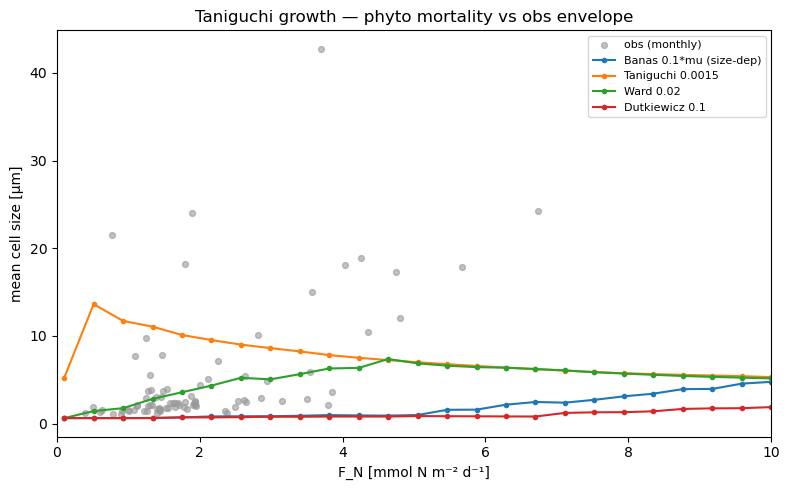

In [18]:
# ── Cell M — literature phyto-mortality comparison × F_N (Taniguchi growth) ──
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu):
    importlib.reload(m)
from xso.parscans import run_xso_parscan

pe, ze = cns.phyto_esd, cns.zoo_esd
bin_defs = co.TARGET_BIN_DEFINITIONS
TAIL = 1000
FN_VALUES = np.linspace(0.1, 10.0, 25)

# literature LINEAR phyto-mortality treatments (Taniguchi growth baked into the setup)
mort = {
    'Banas 0.1*mu (size-dep)': 0.1 * cns.mu_max_tani,    # = mP_tani, the consistent Banas rule
    'Taniguchi 0.0015':        np.full(len(pe), 0.0015),
    'Ward 0.02':               np.full(len(pe), 0.02),
    'Dutkiewicz 0.1':          np.full(len(pe), 0.1),
}

# sweep at upwelling d_e/T; Inflow__FN is the scan axis so it must NOT be in fixed_overrides
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed_forc = {k: v for k, v in forc.items() if k != 'Inflow__FN'}

results = {}
for lab, mP in mort.items():
    res = run_xso_parscan(
        model_file_name='cariaco_npzd_setups', model_name='model_npzd',
        model_setup_name='model_setup_npzd_tani_scan',
        param_name='Inflow__FN', param_values=FN_VALUES, processes=8,
        fixed_overrides={**fixed_forc, 'PhytoMortality__rate': mP})
    rows = []
    for k in range(len(FN_VALUES)):
        proc = pu.process_regime_run(res.isel({'Inflow__FN': k}), pe, ze, bin_defs, tail_len=TAIL)
        Ps = np.asarray(proc['Pspec']); nco = int((Ps > 0.01 * Ps.max()).sum())
        pb = np.asarray(proc['phyto_bins_tail'])
        fr = np.nanmedian(pb / np.clip(pb.sum(0, keepdims=True), 1e-12, None), axis=1)
        rows.append((FN_VALUES[k], np.nanmedian(proc['mcs_tail']), fr[0], fr[1], fr[2], proc['cv'], nco))
    results[lab] = np.array(rows)
    print(f"\n{lab}:   {'F_N':>5}{'mcs':>6}{'Pi':>5}{'Na':>5}{'Mi':>5}{'cv':>6}{'ncl':>4}")
    for r in results[lab]:
        print(f"  {'':>4}{r[0]:5.1f}{r[1]:6.1f}{r[2]:5.2f}{r[3]:5.2f}{r[4]:5.2f}{r[5]:6.2f}{int(r[6]):4d}")

# obs envelope: per-month mcs vs F_N (both regimes), aligned row-wise
pcols = [b['column'] for b in bin_defs if b['type'] == 'phyto']
geo = np.asarray(pu.CARIACO_PHYTO_BIN_GEOMEANS, float)
obs_fn, obs_mcs = [], []
for r in ('upwelling', 'relaxed'):
    *_, mdf, _ = co.load_cariaco_targets(regime=r, months='hplc', agg='median', include_temperature=True)
    sub = mdf[pcols + ['FN_mmolN_m2_d']].dropna()
    P = sub[pcols].values; frac = P / P.sum(1, keepdims=True)
    obs_mcs.append(10 ** (frac @ np.log10(geo))); obs_fn.append(sub['FN_mmolN_m2_d'].values)
obs_fn, obs_mcs = np.concatenate(obs_fn), np.concatenate(obs_mcs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(obs_fn, obs_mcs, s=18, c='0.6', alpha=0.6, label='obs (monthly)')
for lab, arr in results.items():
    ax.plot(arr[:, 0], arr[:, 1], 'o-', ms=3, label=lab)
ax.set_xlim(0, 10); ax.set_xlabel('F_N [mmol N m⁻² d⁻¹]'); ax.set_ylabel('mean cell size [µm]')
ax.set_title('Taniguchi growth — phyto mortality vs obs envelope'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()